# Cursor SWE-bench Analysis

This notebook provides a comprehensive analysis of different AI models' performance on the SWE-bench Lite dataset using Cursor IDE.

## Models Compared
- **Claude 4 Sonnet**: Latest Claude model
- **Auto**: Cursor's automatic model selection
- **Gemini 2.5 Pro**: Google's latest model
- **GPT-4.1**: OpenAI's GPT-4 Turbo

## Dataset
SWE-bench Lite: A curated subset of real-world GitHub issues from popular Python repositories.


In [26]:
# Import required libraries
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10


In [27]:
# Load evaluation data
evaluation_files = {
    'Claude 4 Sonnet': 'data/cursor_evaluation/cursor.cursor_evaluation.json',
    'Auto': 'data/cursor_evaluation/cursor.auto_evaluation.json', 
    'Gemini 2.5 Pro': 'data/cursor_evaluation/cursor.gemini_evaluation.json',
    'GPT-4.1': 'data/cursor_evaluation/cursor.gpt_evaluation.json'
}

data = {}
for name, filename in evaluation_files.items():
    try:
        with open(filename, 'r') as f:
            data[name] = json.load(f)
        print(f"Loaded {name} data")
    except FileNotFoundError:
        print(f"Could not find {filename}")
    except json.JSONDecodeError:
        print(f"Could not parse {filename}")

models = list(data.keys())
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

print(f"\nLoaded data for {len(models)} models: {', '.join(models)}")


Loaded Claude 4 Sonnet data
Loaded Auto data
Loaded Gemini 2.5 Pro data
Loaded GPT-4.1 data

Loaded data for 4 models: Claude 4 Sonnet, Auto, Gemini 2.5 Pro, GPT-4.1


## Data Overview


In [28]:
# Create summary DataFrame
summary_data = []
for model in models:
    resolved = data[model]['resolved_instances']
    unresolved = data[model]['unresolved_instances']
    total = resolved + unresolved
    success_rate = (resolved / total * 100) if total > 0 else 0
    
    summary_data.append({
        'Model': model,
        'Resolved': resolved,
        'Unresolved': unresolved,
        'Total': total,
        'Success Rate (%)': round(success_rate, 1)
    })

summary_df = pd.DataFrame(summary_data)
print("📊 Model Performance Summary:")
print(summary_df.to_string(index=False))


📊 Model Performance Summary:
          Model  Resolved  Unresolved  Total  Success Rate (%)
Claude 4 Sonnet        23           7     30              76.7
           Auto        16          14     30              53.3
 Gemini 2.5 Pro        15          15     30              50.0
        GPT-4.1        15          15     30              50.0


## 1. Success Rate Comparison

This chart shows the percentage of successfully resolved instances for each model.


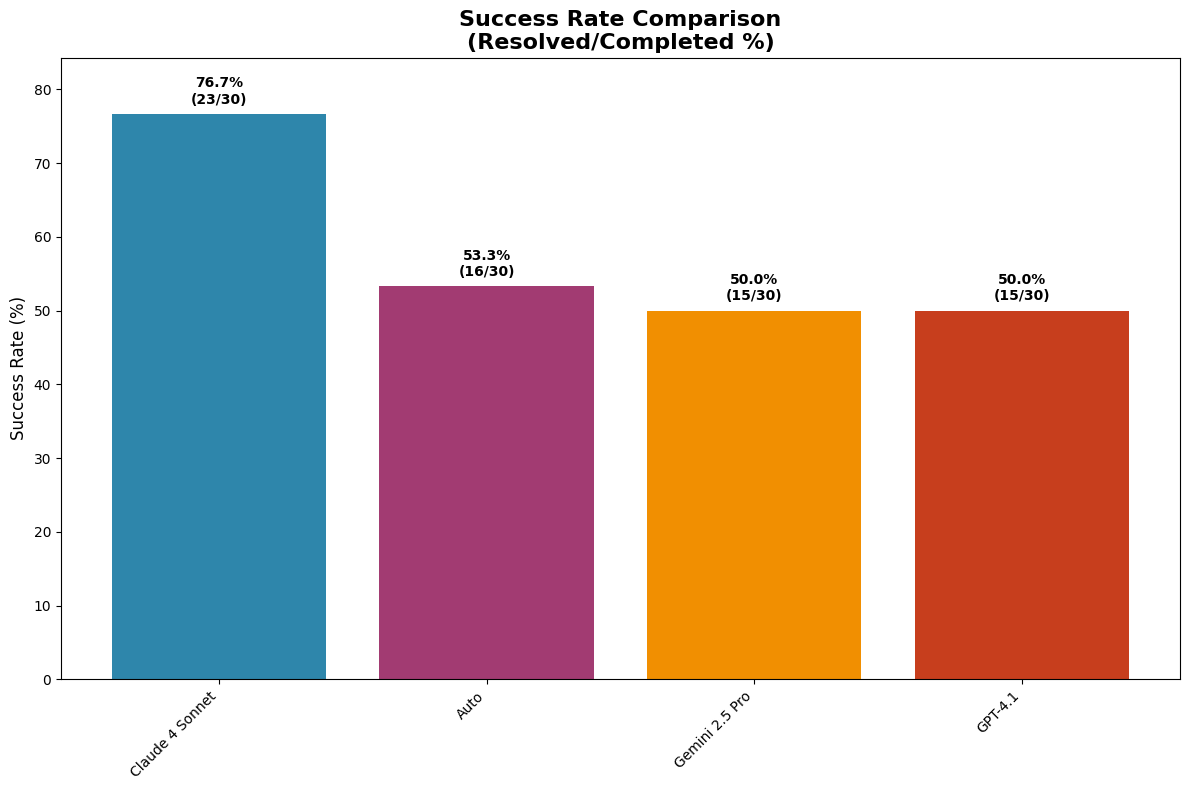

 Best performing model: Claude 4 Sonnet with 76.7% success rate


In [29]:
# Success Rate Comparison
resolved_counts = [data[model]['resolved_instances'] for model in models]
completed_counts = [data[model]['completed_instances'] for model in models]
success_rates = [resolved/completed*100 if completed > 0 else 0 for resolved, completed in zip(resolved_counts, completed_counts)]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(models, success_rates, color=colors)
ax.set_title('Success Rate Comparison\n(Resolved/Completed %)', fontsize=16, fontweight='bold')
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.set_ylim(0, max(success_rates) * 1.1 if success_rates else 100)

# Add value labels on bars
for bar, rate, resolved, completed in zip(bars, success_rates, resolved_counts, completed_counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{rate:.1f}%\n({resolved}/{completed})', ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Key insights
best_model = models[success_rates.index(max(success_rates))]
best_rate = max(success_rates)
print(f" Best performing model: {best_model} with {best_rate:.1f}% success rate")


## 2. Instance Completion Matrix

This heatmap shows which instances each model successfully resolved (green) or failed to resolve (red).


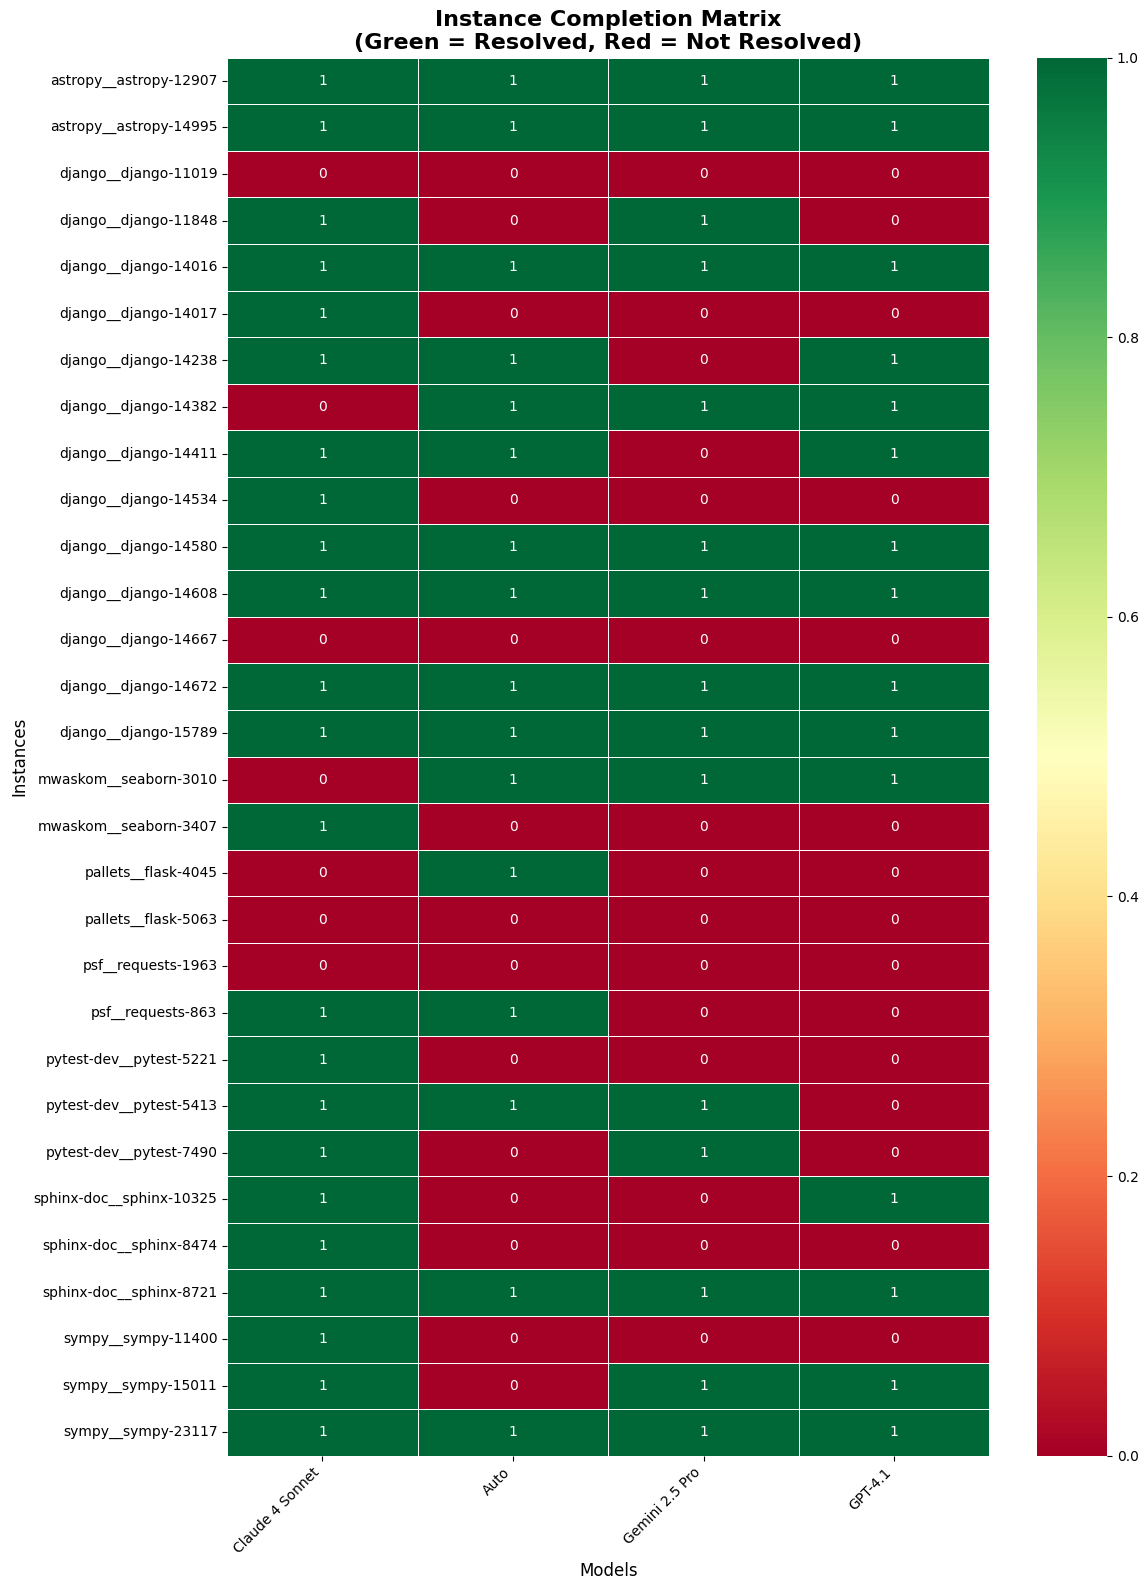

In [30]:
# Instance Completion Matrix (Heatmap)
all_submitted = set(data[models[0]]['submitted_ids']) if models else set()
instance_list = sorted(list(all_submitted))

# Create completion matrix
completion_matrix = []
for instance in instance_list:
    row = []
    for model in models:
        resolved_ids = set(data[model]['resolved_ids'])
        row.append(1 if instance in resolved_ids else 0)
    completion_matrix.append(row)

# Create DataFrame for better visualization
df_matrix = pd.DataFrame(completion_matrix, index=instance_list, columns=models)

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 16))
sns.heatmap(df_matrix, annot=True, cmap='RdYlGn', cbar=True, 
            xticklabels=True, yticklabels=True, ax=ax, 
            square=False, linewidths=0.5)
ax.set_title('Instance Completion Matrix\n(Green = Resolved, Red = Not Resolved)', fontsize=16, fontweight='bold')
ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Instances', fontsize=12)

# Rotate x-axis labels for better readability
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()


## 3. Instance Difficulty Analysis

This chart ranks instances by difficulty, measured by how many models successfully resolved each instance.


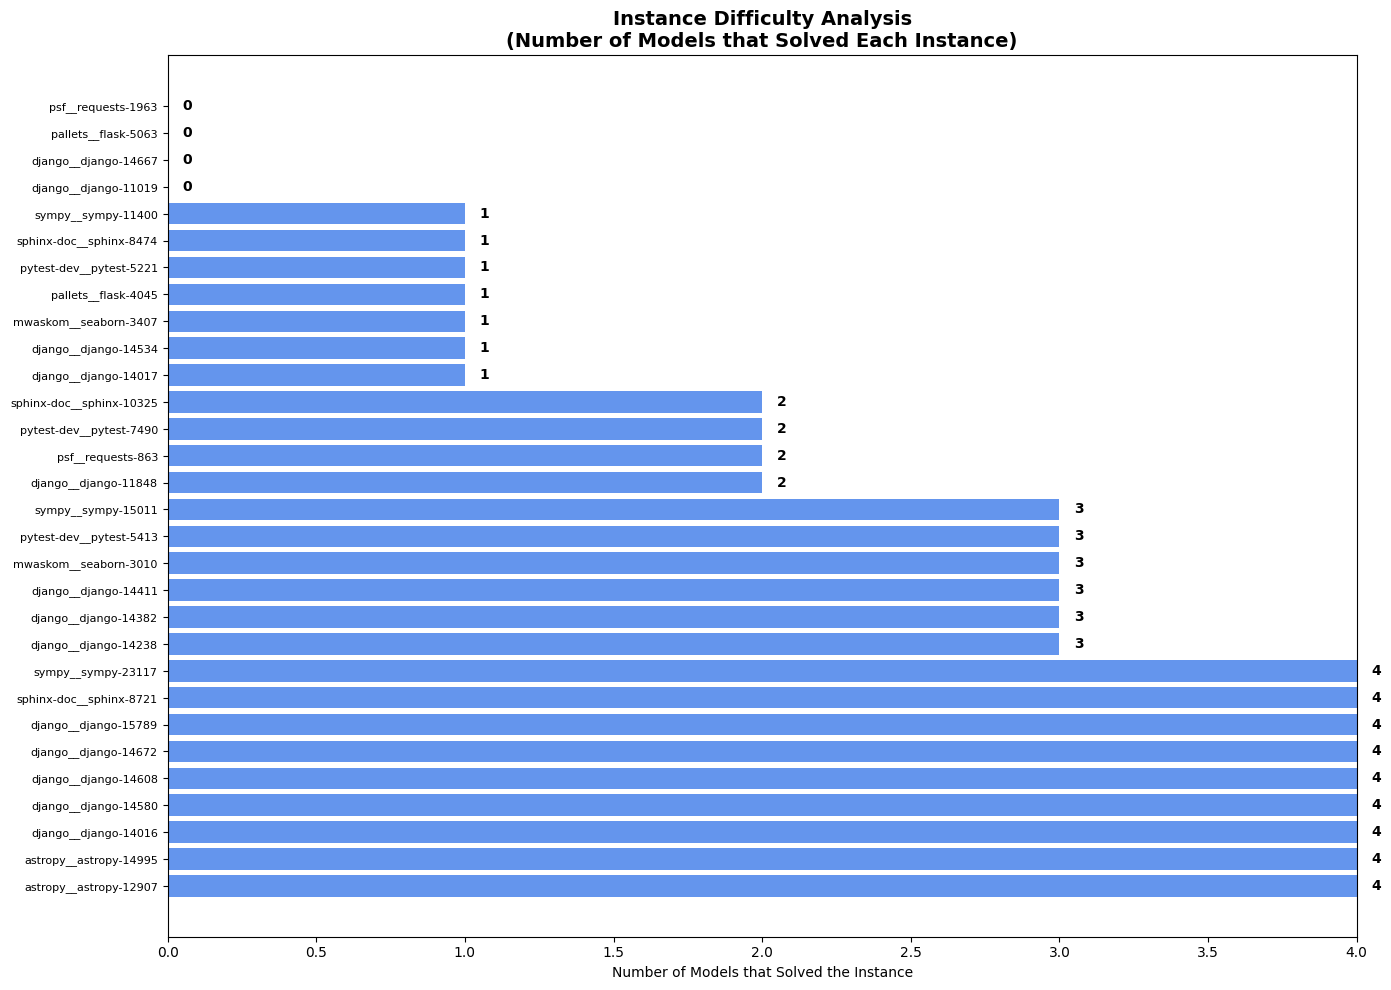

Easiest instances (solved by all 4 models): 9
Hardest instances (solved by no models): 4


In [31]:
# Instance Difficulty Analysis
instance_counts = {}
for instance in instance_list:
    count = 0
    for model in models:
        if instance in set(data[model]['resolved_ids']):
            count += 1
    instance_counts[instance] = count

# Sort instances by how many models solved them
sorted_instances = sorted(instance_counts.items(), key=lambda x: x[1], reverse=True)
instance_names = [item[0] for item in sorted_instances]
solver_counts = [item[1] for item in sorted_instances]


fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(range(len(instance_names)), solver_counts, color="cornflowerblue")
ax.set_yticks(range(len(instance_names)))
ax.set_yticklabels(instance_names, fontsize=8)
ax.set_xlabel('Number of Models that Solved the Instance')
ax.set_title('Instance Difficulty Analysis\n(Number of Models that Solved Each Instance)', fontsize=14, fontweight='bold')
ax.set_xlim(0, len(models))

# Add value labels on bars
for i, (bar, count) in enumerate(zip(bars, solver_counts)):
    width = bar.get_width()
    ax.text(width + 0.05, bar.get_y() + bar.get_height()/2.,
             f'{count}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Difficulty insights
easy_instances = [name for name, count in sorted_instances if count == len(models)]
hard_instances = [name for name, count in sorted_instances if count == 0]

print(f"Easiest instances (solved by all {len(models)} models): {len(easy_instances)}")
print(f"Hardest instances (solved by no models): {len(hard_instances)}")


## 4. Model Comparison Analysis


In [32]:
# Model-specific unique resolutions
resolved_by_model = {}
for model in models:
    resolved_by_model[model] = set(data[model]['resolved_ids'])

print(" Model-Specific Analysis:\n")

# Find instances resolved by each model exclusively
for model in models:
    other_models = [m for m in models if m != model]
    other_resolved = set.union(*[resolved_by_model[m] for m in other_models]) if other_models else set()
    unique_to_model = resolved_by_model[model] - other_resolved
    
    print(f"**{model}:**")
    print(f"  - Total resolved: {len(resolved_by_model[model])}")
    print(f"  - Unique resolutions: {len(unique_to_model)}")
    if unique_to_model:
        print(f"  - Unique instances: {', '.join(sorted(unique_to_model))}")
    print()


 Model-Specific Analysis:

**Claude 4 Sonnet:**
  - Total resolved: 23
  - Unique resolutions: 6
  - Unique instances: django__django-14017, django__django-14534, mwaskom__seaborn-3407, pytest-dev__pytest-5221, sphinx-doc__sphinx-8474, sympy__sympy-11400

**Auto:**
  - Total resolved: 16
  - Unique resolutions: 1
  - Unique instances: pallets__flask-4045

**Gemini 2.5 Pro:**
  - Total resolved: 15
  - Unique resolutions: 0

**GPT-4.1:**
  - Total resolved: 15
  - Unique resolutions: 0



In [33]:
# Overlap analysis
all_resolved = set.intersection(*[resolved_by_model[model] for model in models])
none_resolved = all_submitted - set.union(*[resolved_by_model[model] for model in models])

print(f" Consensus Analysis:")
print(f"  - Instances resolved by ALL models: {len(all_resolved)}")
print(f"  - Instances resolved by NO models: {len(none_resolved)}")
print(f"  - Total instances evaluated: {len(all_submitted)}")

if all_resolved:
    print(f"\n Universally resolved instances:")
    for instance in sorted(all_resolved):
        print(f"  - {instance}")

if none_resolved:
    print(f"\n Universally failed instances:")
    for instance in sorted(none_resolved):
        print(f"  - {instance}")


 Consensus Analysis:
  - Instances resolved by ALL models: 9
  - Instances resolved by NO models: 4
  - Total instances evaluated: 30

 Universally resolved instances:
  - astropy__astropy-12907
  - astropy__astropy-14995
  - django__django-14016
  - django__django-14580
  - django__django-14608
  - django__django-14672
  - django__django-15789
  - sphinx-doc__sphinx-8721
  - sympy__sympy-23117

 Universally failed instances:
  - django__django-11019
  - django__django-14667
  - pallets__flask-5063
  - psf__requests-1963


## 5. Repository Analysis

Let's analyze performance by repository to identify patterns.


In [34]:
# Extract repository information from instance names
repo_performance = {}

for instance in instance_list:
    # Extract repo name (assuming format: repo_owner__repo_name-issue_id)
    parts = instance.split('__')
    if len(parts) >= 2:
        repo_name = parts[0] + '__' + parts[1].split('-')[0]
    else:
        repo_name = instance.split('-')[0]
    
    if repo_name not in repo_performance:
        repo_performance[repo_name] = {'total': 0, 'resolved_by_model': {model: 0 for model in models}}
    
    repo_performance[repo_name]['total'] += 1
    
    for model in models:
        if instance in resolved_by_model[model]:
            repo_performance[repo_name]['resolved_by_model'][model] += 1

# Create repository performance DataFrame
repo_data = []
for repo, stats in repo_performance.items():
    row = {'Repository': repo, 'Total_Issues': stats['total']}
    for model in models:
        resolved = stats['resolved_by_model'][model]
        rate = (resolved / stats['total'] * 100) if stats['total'] > 0 else 0
        row[f'{model}_Resolved'] = resolved
        row[f'{model}_Rate'] = round(rate, 1)
    repo_data.append(row)

repo_df = pd.DataFrame(repo_data)
repo_df = repo_df.sort_values('Total_Issues', ascending=False)

print(" Repository Performance Summary:")
print(repo_df[['Repository', 'Total_Issues'] + [f'{model}_Rate' for model in models]].to_string(index=False))


 Repository Performance Summary:
        Repository  Total_Issues  Claude 4 Sonnet_Rate  Auto_Rate  Gemini 2.5 Pro_Rate  GPT-4.1_Rate
    django__django            13                  76.9       61.5                 53.8          61.5
pytest-dev__pytest             3                 100.0       33.3                 66.7           0.0
sphinx-doc__sphinx             3                 100.0       33.3                 33.3          66.7
      sympy__sympy             3                 100.0       33.3                 66.7          66.7
  astropy__astropy             2                 100.0      100.0                100.0         100.0
  mwaskom__seaborn             2                  50.0       50.0                 50.0          50.0
    pallets__flask             2                   0.0       50.0                  0.0           0.0
     psf__requests             2                  50.0       50.0                  0.0           0.0


## 6. Key Insights


In [ ]:
print("Key Insights:\n")

# Find best and worst performing models
success_rates_dict = {models[i]: success_rates[i] for i in range(len(models))}
best_model = max(success_rates_dict, key=success_rates_dict.get)
worst_model = min(success_rates_dict, key=success_rates_dict.get)

print(f"1. Best Overall Performance: {best_model} ({success_rates_dict[best_model]:.1f}% success rate)")
print(f"2. Most Room for Improvement: {worst_model} ({success_rates_dict[worst_model]:.1f}% success rate)")

# Calculate consensus score
consensus_rate = len(all_resolved) / len(all_submitted) * 100 if all_submitted else 0
print(f"3. Consensus Success Rate: {consensus_rate:.1f}% (instances all models agree on)")

# Find most challenging repositories
if not repo_df.empty:
    avg_rates = []
    for _, row in repo_df.iterrows():
        rates = [row[f'{model}_Rate'] for model in models]
        avg_rates.append(np.mean(rates))
    repo_df['Avg_Success_Rate'] = avg_rates
    
    easiest_repo = repo_df.loc[repo_df['Avg_Success_Rate'].idxmax(), 'Repository']
    hardest_repo = repo_df.loc[repo_df['Avg_Success_Rate'].idxmin(), 'Repository']
    
    print(f"4. Easiest Repository: {easiest_repo}")
    print(f"5. Most Challenging Repository: {hardest_repo}")

print(f"\n Overall Statistics:")
print(f"  - Total instances evaluated: {len(all_submitted)}")
print(f"  - Average success rate across all models: {np.mean(success_rates):.1f}%")
print(f"  - Standard deviation: {np.std(success_rates):.1f}%")





Key Insights:

1. Best Overall Performance: Claude 4 Sonnet (76.7% success rate)
2. Most Room for Improvement: Gemini 2.5 Pro (50.0% success rate)
3. **Consensus Success Rate:** 30.0% (instances all models agree on)
4. Easiest Repository: astropy__astropy
5. Most Challenging Repository: pallets__flask

 Overall Statistics:
  - Total instances evaluated: 30
  - Average success rate across all models: 57.5%
  - Standard deviation: 11.1%


- Claude 4 Sonnet is the best performing model with a success rate of 76.7%
- Although Claude 4 Sonnet is the best performing model, it was also took the longest time to complete the tasks.
- Claude 4 Sonnet extensively tests the codebase after making changes, which contributes to its high success rate and long run time.
- Gemini 2.5 Pro excels in deep learning tasks, by performing a lot of web searches, but it was one of the worst perfomring models.
- GPT-4.1 is tied for the worst performing model, but it was the fastest model to complete the tasks.

## 7. Export Results

Save the analysis results for further use.


In [36]:
# Export comprehensive results
export_data = {
    'summary': summary_df.to_dict('records'),
    'instance_matrix': df_matrix.to_dict(),
    'repository_performance': repo_df.to_dict('records') if not repo_df.empty else [],
    'consensus_resolved': sorted(list(all_resolved)),
    'never_resolved': sorted(list(none_resolved)),
    'model_unique_resolutions': {
        model: sorted(list(resolved_by_model[model] - set.union(*[resolved_by_model[m] for m in models if m != model])))
        for model in models
    }
}

# Save to JSON
with open('cursor_analysis_results.json', 'w') as f:
    json.dump(export_data, f, indent=2)

# Save summary to CSV
summary_df.to_csv('cursor_model_summary.csv', index=False)

print(" Results exported:")
print("  - cursor_analysis_results.json (comprehensive data)")
print("  - cursor_model_summary.csv (summary table)")
print("\n Analysis complete!")


 Results exported:
  - cursor_analysis_results.json (comprehensive data)
  - cursor_model_summary.csv (summary table)

 Analysis complete!
